In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
df = pd.read_csv(r"C:\Users\Krishnakumar\Desktop\Student_Dropout_prediction\New folder\student_dropout_early_warning.csv")
df

,Student_ID,Age,Attendance_Percentage,Previous_GPA,Current_GPA,Failed_Subjects,Assignment_Completion_Percentage,Study_Hours_Per_Week,Late_Submissions,LMS_Logins_Per_Week,...,Previous_Backlogs,Financial_Stress,Commute_Time_Minutes,Internet_Access,Scholarship,Academic_Support,Parent_Education,Extracurricular_Hours_Per_Week,Sleep_Hours_Per_Night,Dropout_Risk
0,STU100000,22,100.0,6.24,6.18,2,83.1,17.0,0,15.0,...,2,5.0,22.0,Yes,No,No,Undergraduate,8,5.7,Low
1,STU100001,20,74.9,6.79,6.91,1,69.2,11.5,5,14.0,...,3,6.1,33.0,No,No,No,School,7,4.9,Medium
2,STU100002,24,93.1,6.29,8.38,0,88.8,20.9,1,7.0,...,0,2.2,5.0,Yes,No,No,Diploma,8,8.5,Low
3,STU100003,18,92.8,8.92,9.14,0,79.9,24.3,9,13.0,...,0,3.9,19.0,Yes,Yes,No,Undergraduate,6,8.8,Low
4,STU100004,17,81.4,4.71,3.64,1,79.7,9.3,8,7.0,...,2,3.2,37.0,Yes,Yes,No,Postgraduate,5,7.0,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,STU114995,21,75.6,9.20,9.29,1,79.6,20.9,8,6.0,...,1,5.7,57.0,Yes,No,No,Postgraduate,5,7.1,Low
14996,STU114996,20,94.1,7.08,7.73,1,62.9,14.3,7,7.0,...,1,4.7,23.0,Yes,Yes,No,Undergraduate,9,9.2,Low
14997,STU114997,18,91.8,5.76,6.73,2,73.5,36.3,0,12.0,...,3,5.0,82.0,Yes,No,Yes,Diploma,14,6.4,Low
14998,STU114998,21,73.1,4.68,4.70,2,70.3,9.7,9,9.0,...,1,6.1,50.0,Yes,No,Yes,Undergraduate,5,6.6,Medium


In [7]:
#  checking the size

df.shape

(15000, 21)

In [8]:
# print first 5 students

df.head()

,Student_ID,Age,Attendance_Percentage,Previous_GPA,Current_GPA,Failed_Subjects,Assignment_Completion_Percentage,Study_Hours_Per_Week,Late_Submissions,LMS_Logins_Per_Week,...,Previous_Backlogs,Financial_Stress,Commute_Time_Minutes,Internet_Access,Scholarship,Academic_Support,Parent_Education,Extracurricular_Hours_Per_Week,Sleep_Hours_Per_Night,Dropout_Risk
0,STU100000,22,100.0,6.24,6.18,2,83.1,17.0,0,15.0,...,2,5.0,22.0,Yes,No,No,Undergraduate,8,5.7,Low
1,STU100001,20,74.9,6.79,6.91,1,69.2,11.5,5,14.0,...,3,6.1,33.0,No,No,No,School,7,4.9,Medium
2,STU100002,24,93.1,6.29,8.38,0,88.8,20.9,1,7.0,...,0,2.2,5.0,Yes,No,No,Diploma,8,8.5,Low
3,STU100003,18,92.8,8.92,9.14,0,79.9,24.3,9,13.0,...,0,3.9,19.0,Yes,Yes,No,Undergraduate,6,8.8,Low
4,STU100004,17,81.4,4.71,3.64,1,79.7,9.3,8,7.0,...,2,3.2,37.0,Yes,Yes,No,Postgraduate,5,7.0,Medium


In [9]:
#  print last 5 students

df.tail()

,Student_ID,Age,Attendance_Percentage,Previous_GPA,Current_GPA,Failed_Subjects,Assignment_Completion_Percentage,Study_Hours_Per_Week,Late_Submissions,LMS_Logins_Per_Week,...,Previous_Backlogs,Financial_Stress,Commute_Time_Minutes,Internet_Access,Scholarship,Academic_Support,Parent_Education,Extracurricular_Hours_Per_Week,Sleep_Hours_Per_Night,Dropout_Risk
14995,STU114995,21,75.6,9.20,9.29,1,79.6,20.9,8,6.0,...,1,5.7,57.0,Yes,No,No,Postgraduate,5,7.1,Low
14996,STU114996,20,94.1,7.08,7.73,1,62.9,14.3,7,7.0,...,1,4.7,23.0,Yes,Yes,No,Undergraduate,9,9.2,Low
14997,STU114997,18,91.8,5.76,6.73,2,73.5,36.3,0,12.0,...,3,5.0,82.0,Yes,No,Yes,Diploma,14,6.4,Low
14998,STU114998,21,73.1,4.68,4.70,2,70.3,9.7,9,9.0,...,1,6.1,50.0,Yes,No,Yes,Undergraduate,5,6.6,Medium
14999,STU114999,21,51.4,5.58,4.02,3,71.9,10.0,16,5.0,...,0,7.2,48.0,Yes,No,No,Postgraduate,4,9.0,High


In [10]:
# checking column names
df.columns

Index(['Student_ID', 'Age', 'Attendance_Percentage', 'Previous_GPA',
       'Current_GPA', 'Failed_Subjects', 'Assignment_Completion_Percentage',
       'Study_Hours_Per_Week', 'Late_Submissions', 'LMS_Logins_Per_Week',
       'Class_Participation_Percentage', 'Previous_Backlogs',
       'Financial_Stress', 'Commute_Time_Minutes', 'Internet_Access',
       'Scholarship', 'Academic_Support', 'Parent_Education',
       'Extracurricular_Hours_Per_Week', 'Sleep_Hours_Per_Night',
       'Dropout_Risk'],
      dtype='str')

In [11]:
# understanding the datatypes

df.dtypes

Student_ID                              str
Age                                   int64
Attendance_Percentage               float64
Previous_GPA                        float64
Current_GPA                         float64
Failed_Subjects                       int64
Assignment_Completion_Percentage    float64
Study_Hours_Per_Week                float64
Late_Submissions                      int64
LMS_Logins_Per_Week                 float64
Class_Participation_Percentage      float64
Previous_Backlogs                     int64
Financial_Stress                    float64
Commute_Time_Minutes                float64
Internet_Access                         str
Scholarship                             str
Academic_Support                        str
Parent_Education                        str
Extracurricular_Hours_Per_Week        int64
Sleep_Hours_Per_Night               float64
Dropout_Risk                            str
dtype: object

In [12]:
# checking missing values

df.isna().sum()

Student_ID                            0
Age                                   0
Attendance_Percentage               150
Previous_GPA                          0
Current_GPA                           0
Failed_Subjects                       0
Assignment_Completion_Percentage    150
Study_Hours_Per_Week                  0
Late_Submissions                      0
LMS_Logins_Per_Week                 150
Class_Participation_Percentage        0
Previous_Backlogs                     0
Financial_Stress                    150
Commute_Time_Minutes                150
Internet_Access                       0
Scholarship                           0
Academic_Support                      0
Parent_Education                      0
Extracurricular_Hours_Per_Week        0
Sleep_Hours_Per_Night                 0
Dropout_Risk                          0
dtype: int64

In [13]:
#  checking duplicates

df.duplicated().sum()

np.int64(0)

In [14]:
#  check the target distribution

df['Dropout_Risk'].value_counts()

Dropout_Risk
Low       9000
Medium    3750
High      2250
Name: count, dtype: int64

In [15]:
# percentage

df['Dropout_Risk'].value_counts(normalize=True)*100

Dropout_Risk
Low       60.0
Medium    25.0
High      15.0
Name: proportion, dtype: float64

In [16]:
#  statistical summary

df.describe()

,Age,Attendance_Percentage,Previous_GPA,Current_GPA,Failed_Subjects,Assignment_Completion_Percentage,Study_Hours_Per_Week,Late_Submissions,LMS_Logins_Per_Week,Class_Participation_Percentage,Previous_Backlogs,Financial_Stress,Commute_Time_Minutes,Extracurricular_Hours_Per_Week,Sleep_Hours_Per_Night
count,15000.000000,14850.000000,15000.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,14850.000000,14850.000000,15000.000000,15000.000000
mean,20.523133,77.834869,6.682715,6.670067,1.505000,75.933650,14.420133,6.054533,8.087677,70.057260,1.301267,5.033717,36.157374,5.170533,7.003613
std,1.961289,13.422554,1.267458,1.794972,1.239547,13.482005,7.819736,3.338947,4.107632,14.708896,1.081750,2.432171,21.494043,3.347626,1.156460
min,17.000000,35.000000,3.000000,2.500000,0.000000,30.000000,2.000000,0.000000,0.000000,20.000000,0.000000,1.000000,5.000000,0.000000,4.000000
25%,19.000000,68.700000,5.820000,5.410000,0.000000,66.700000,8.500000,4.000000,5.000000,60.000000,0.000000,3.200000,19.000000,3.000000,6.200000
50%,20.000000,78.300000,6.690000,6.690000,1.000000,76.200000,14.100000,6.000000,8.000000,70.200000,1.000000,5.000000,35.000000,5.000000,7.000000
75%,22.000000,87.700000,7.530000,7.950000,2.000000,85.600000,19.800000,8.000000,11.000000,80.400000,2.000000,6.800000,51.000000,7.000000,7.800000
max,29.000000,100.000000,10.000000,10.000000,6.000000,100.000000,40.000000,20.000000,24.000000,100.000000,5.000000,10.000000,128.000000,15.000000,10.000000


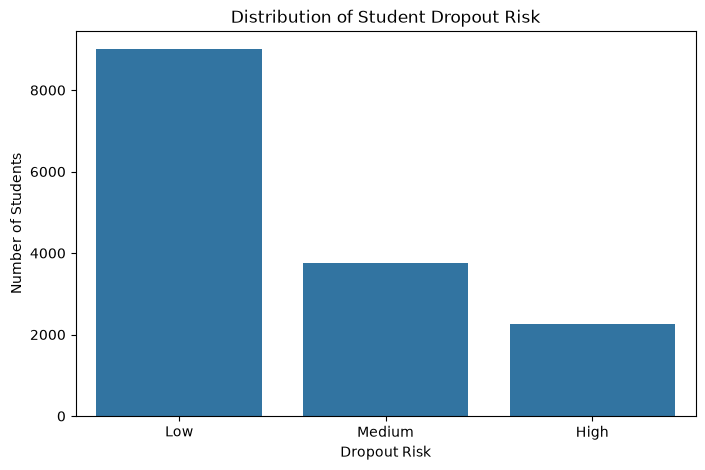

In [17]:
#  looking at the target visually

plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Dropout_Risk')

plt.title('Distribution of Student Dropout Risk')
plt.xlabel('Dropout Risk')
plt.ylabel('Number of Students')

plt.show()

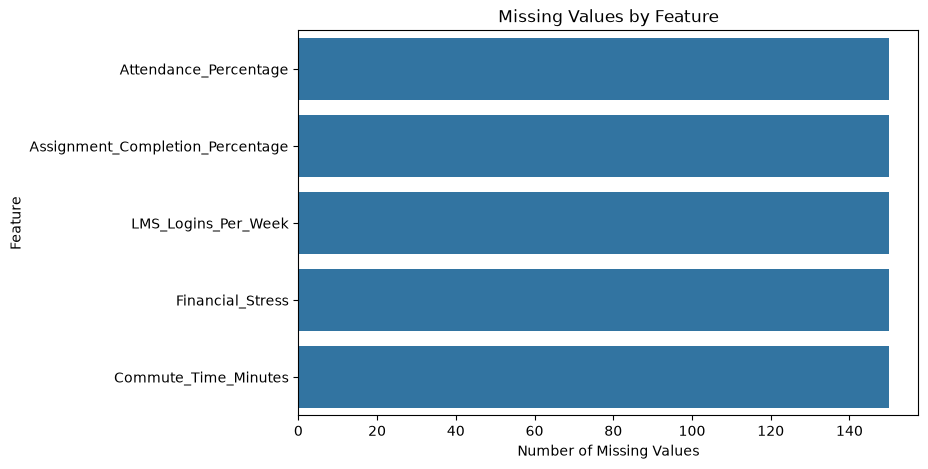

In [18]:
#  missing value visualization

missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(8,5))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title('Missing Values by Feature')
plt.xlabel('Number of Missing Values')
plt.ylabel('Feature')

plt.show()

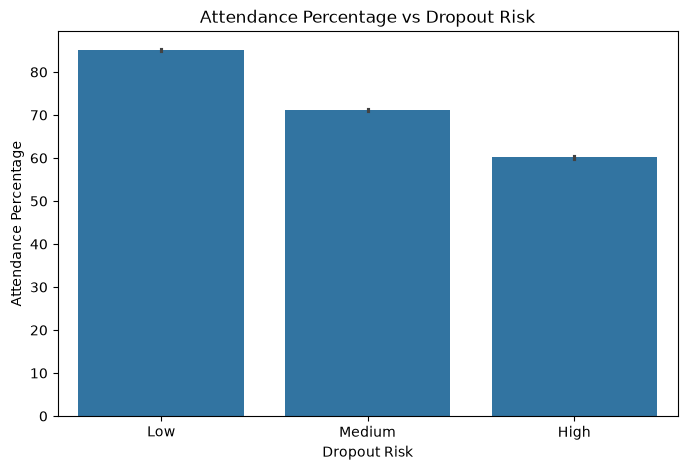

In [19]:
#  attendance vs dropout risk

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Dropout_Risk',
    y='Attendance_Percentage'
)

plt.title('Attendance Percentage vs Dropout Risk')
plt.xlabel('Dropout Risk')
plt.ylabel('Attendance Percentage')

plt.show()

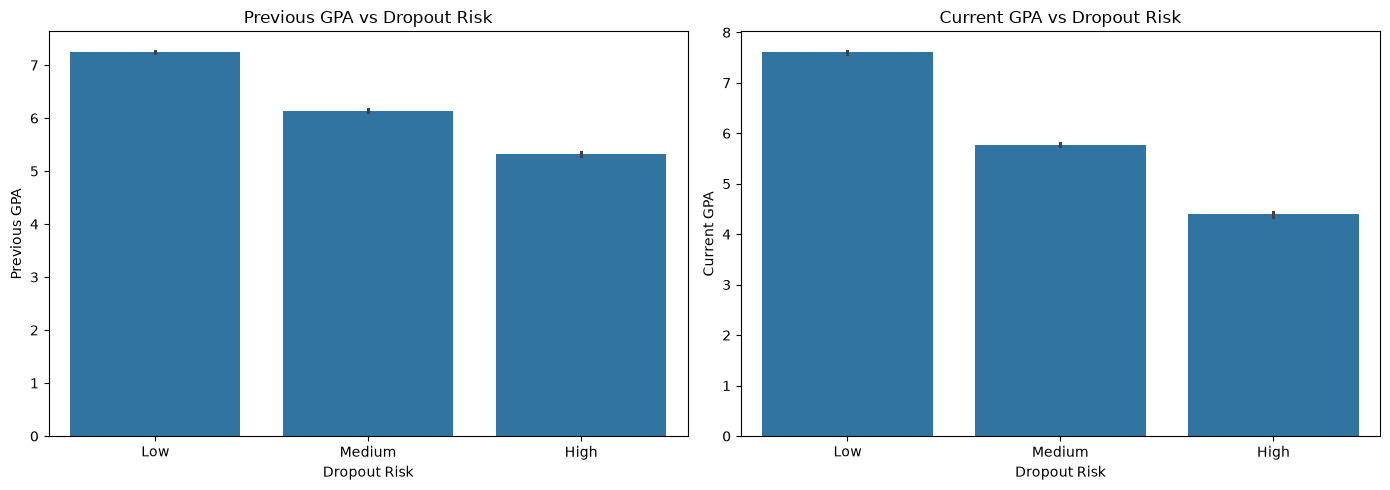

In [20]:
# gpa vs dropout risk

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(
    data=df,
    x='Dropout_Risk',
    y='Previous_GPA',
    ax=axes[0]
)

axes[0].set_title('Previous GPA vs Dropout Risk')
axes[0].set_xlabel('Dropout Risk')
axes[0].set_ylabel('Previous GPA')

sns.barplot(
    data=df,
    x='Dropout_Risk',
    y='Current_GPA',
    ax=axes[1]
)

axes[1].set_title('Current GPA vs Dropout Risk')
axes[1].set_xlabel('Dropout Risk')
axes[1].set_ylabel('Current GPA')

plt.tight_layout()
plt.show()

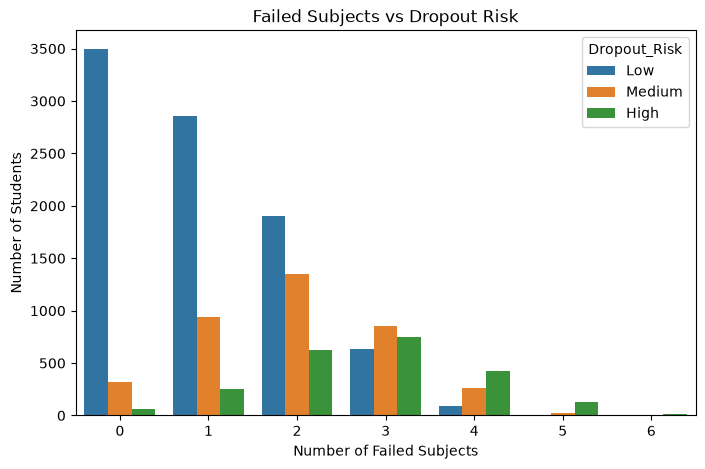

In [21]:
#  failed subjects vs dropout risk

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Failed_Subjects',
    hue='Dropout_Risk'
)

plt.title('Failed Subjects vs Dropout Risk')
plt.xlabel('Number of Failed Subjects')
plt.ylabel('Number of Students')

plt.show()

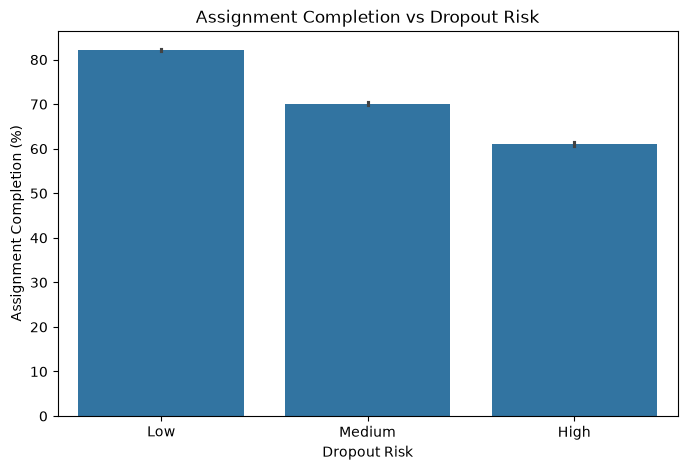

In [22]:
#  assignment completion vs dropout risk

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Dropout_Risk',
    y='Assignment_Completion_Percentage'
)

plt.title('Assignment Completion vs Dropout Risk')
plt.xlabel('Dropout Risk')
plt.ylabel('Assignment Completion (%)')

plt.show()

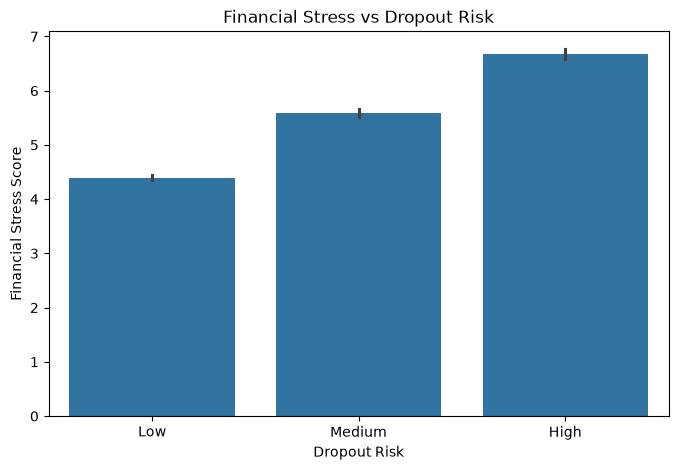

In [23]:
# financial stress vs dropout risk

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Dropout_Risk',
    y='Financial_Stress'
)

plt.title('Financial Stress vs Dropout Risk')
plt.xlabel('Dropout Risk')
plt.ylabel('Financial Stress Score')

plt.show()

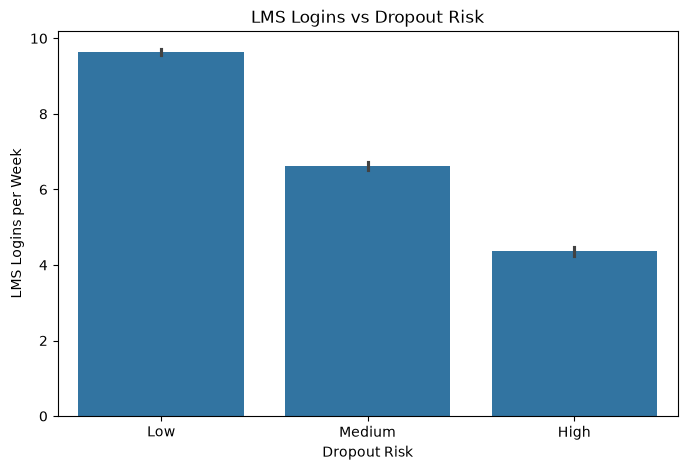

In [24]:
# LMS activity vs dropout risk

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Dropout_Risk',
    y='LMS_Logins_Per_Week'
)

plt.title('LMS Logins vs Dropout Risk')
plt.xlabel('Dropout Risk')
plt.ylabel('LMS Logins per Week')

plt.show()

In [25]:
#  average values for each risk group

risk_summary = df.groupby('Dropout_Risk')[
    [
        'Attendance_Percentage',
        'Previous_GPA',
        'Current_GPA',
        'Failed_Subjects',
        'Assignment_Completion_Percentage',
        'Study_Hours_Per_Week',
        'LMS_Logins_Per_Week',
        'Financial_Stress'
    ]
].mean()

risk_summary

,Attendance_Percentage,Previous_GPA,Current_GPA,Failed_Subjects,Assignment_Completion_Percentage,Study_Hours_Per_Week,LMS_Logins_Per_Week,Financial_Stress
Dropout_Risk,,,,,,,,
High,60.185014,5.317453,4.398578,2.750667,61.004779,6.580667,4.356982,6.675505
Low,85.036210,7.251126,7.610940,0.998778,82.081592,17.883511,9.628142,4.393071
Medium,71.117869,6.137688,5.774864,1.972533,70.080361,10.811707,6.627055,5.583831


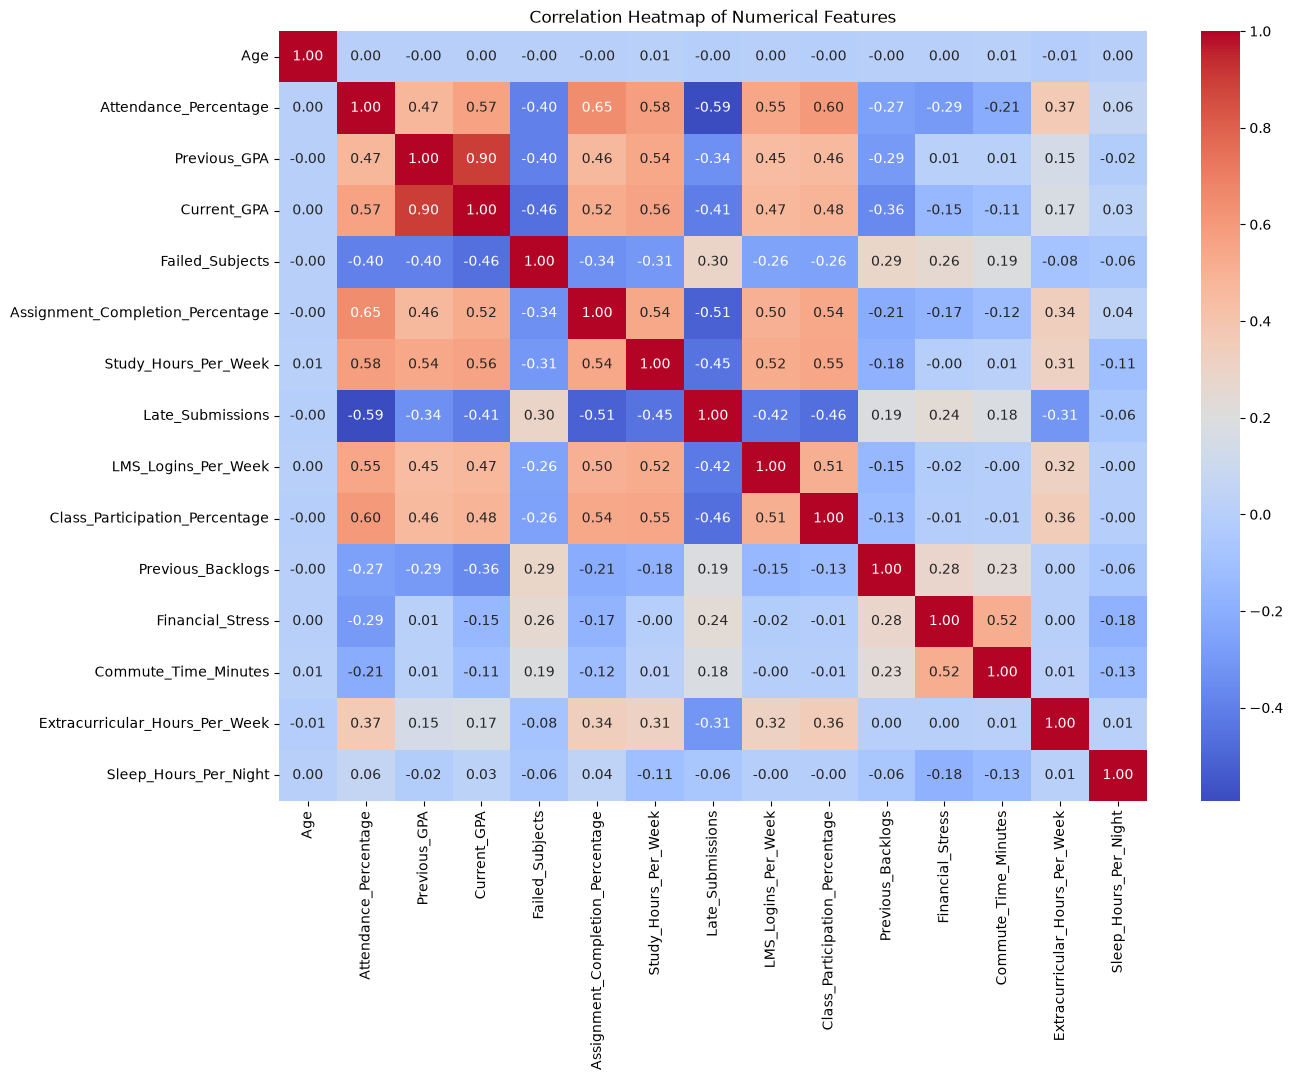

In [26]:
# correlation analysis

plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [27]:
#  feature relationship with dropout risk

risk_summary = df.groupby('Dropout_Risk')[
    [
        'Attendance_Percentage',
        'Previous_GPA',
        'Current_GPA',
        'Failed_Subjects',
        'Assignment_Completion_Percentage',
        'Study_Hours_Per_Week',
        'Late_Submissions',
        'LMS_Logins_Per_Week',
        'Class_Participation_Percentage',
        'Previous_Backlogs',
        'Financial_Stress'
    ]
].mean().round(2)

risk_summary

,Attendance_Percentage,Previous_GPA,Current_GPA,Failed_Subjects,Assignment_Completion_Percentage,Study_Hours_Per_Week,Late_Submissions,LMS_Logins_Per_Week,Class_Participation_Percentage,Previous_Backlogs,Financial_Stress
Dropout_Risk,,,,,,,,,,,
High,60.19,5.32,4.40,2.75,61.00,6.58,9.40,4.36,56.01,2.13,6.68
Low,85.04,7.25,7.61,1.00,82.08,17.88,4.69,9.63,75.98,0.98,4.39
Medium,71.12,6.14,5.77,1.97,70.08,10.81,7.33,6.63,64.28,1.57,5.58


In [28]:
#  categorical EDA

categorical_cols = [
    'Internet_Access',
    'Scholarship',
    'Academic_Support',
    'Parent_Education'
]

for col in categorical_cols:
    print("\n" + "="*60)
    print(col)
    print("="*60)

    result = pd.crosstab(
        df[col],
        df['Dropout_Risk'],
        normalize='index'
    ) * 100

    print(result.round(2))


Internet_Access
Dropout_Risk      High    Low  Medium
Internet_Access                      
No               16.13  55.41   28.46
Yes              14.91  60.37   24.72

Scholarship
Dropout_Risk   High    Low  Medium
Scholarship                       
No            15.34  59.22   25.43
Yes           14.10  62.03   23.87

Academic_Support
Dropout_Risk       High    Low  Medium
Academic_Support                      
No                15.74  59.20   25.06
Yes               13.64  61.46   24.89

Parent_Education
Dropout_Risk       High    Low  Medium
Parent_Education                      
Diploma           14.23  60.43   25.34
Postgraduate      14.65  59.80   25.55
School            15.01  58.98   26.01
Undergraduate     15.59  60.36   24.04


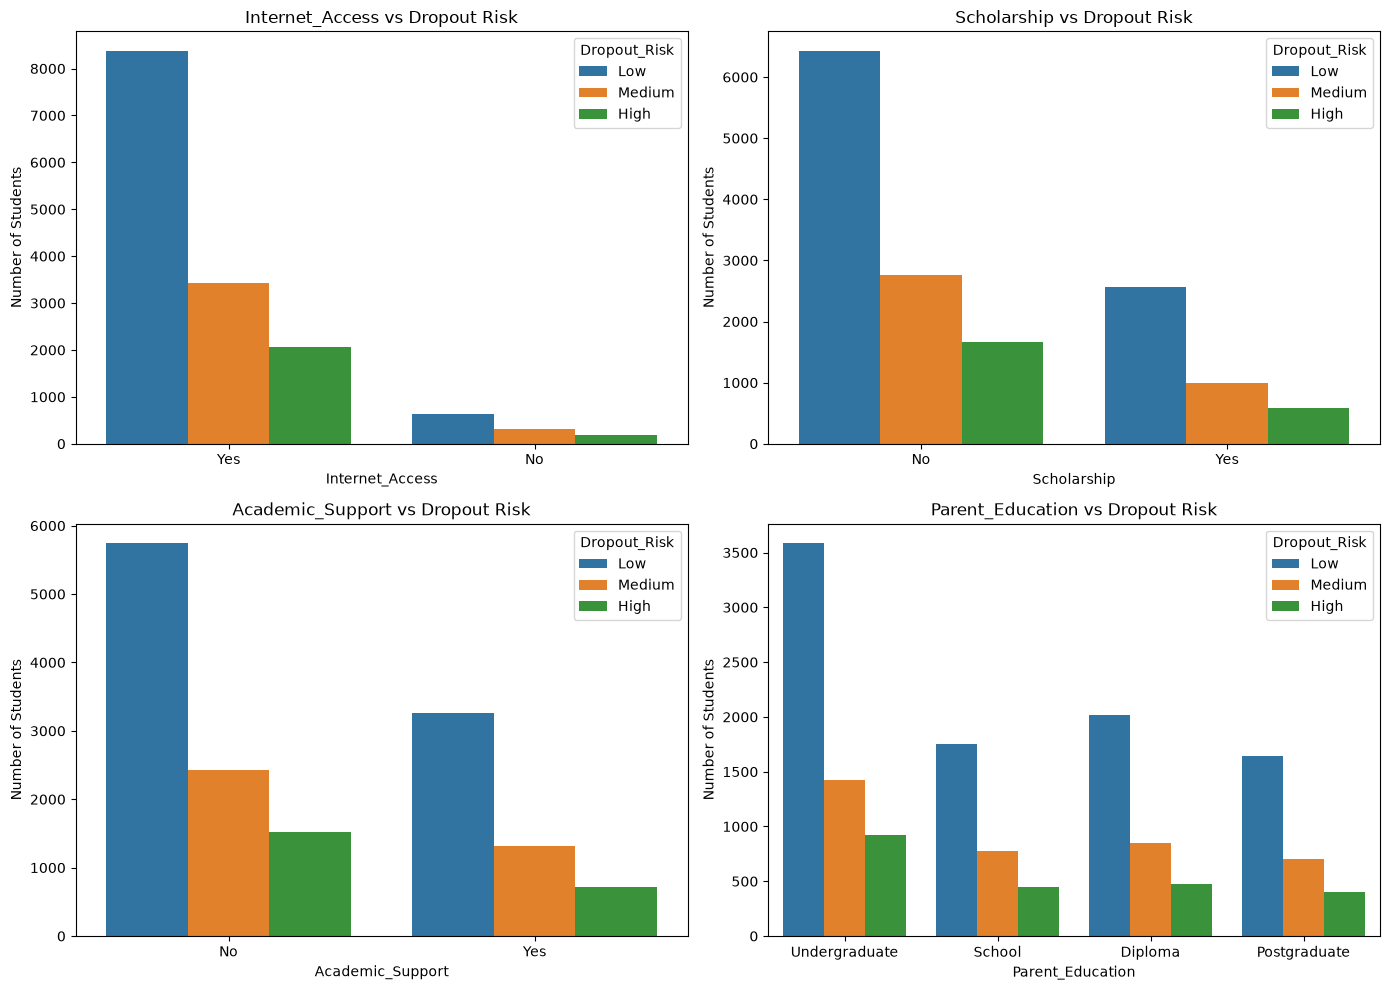

In [29]:
#  visualizing

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        hue='Dropout_Risk',
        ax=ax
    )

    ax.set_title(f'{col} vs Dropout Risk')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of Students')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

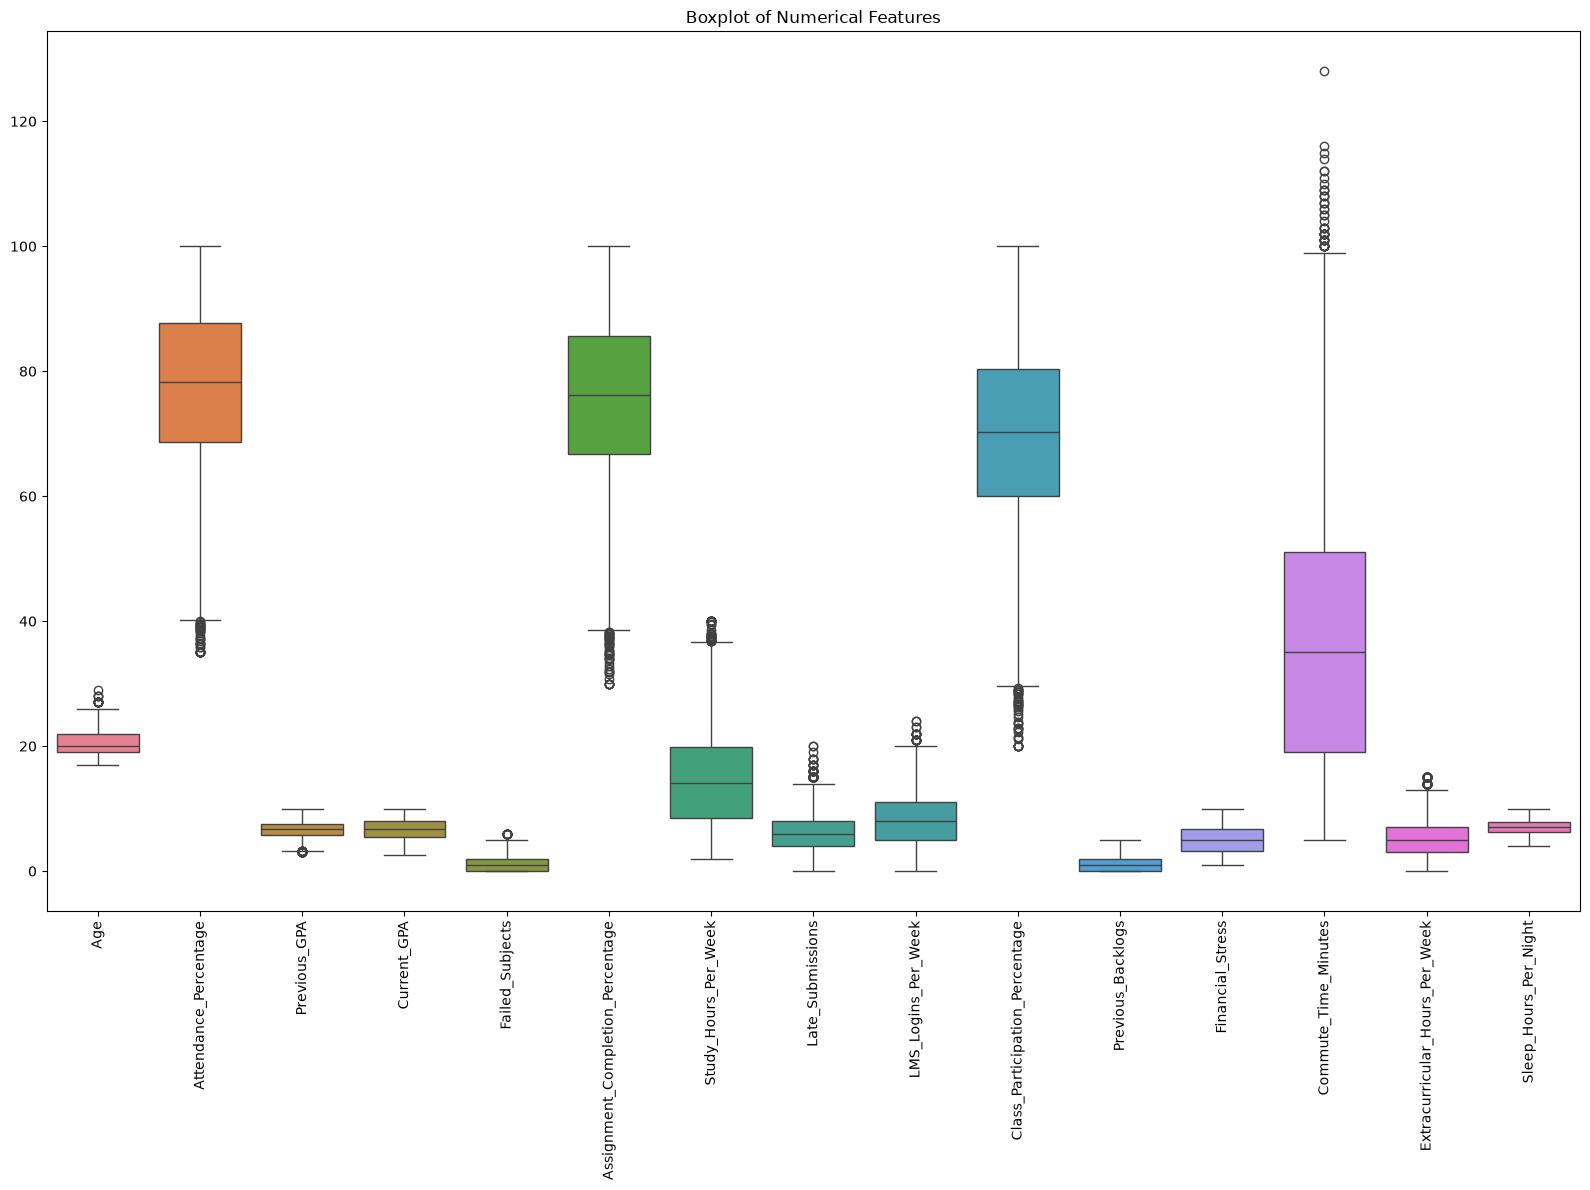

In [30]:
#  checking outliers

numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

plt.figure(figsize=(16, 12))

sns.boxplot(data=df[numeric_cols])

plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

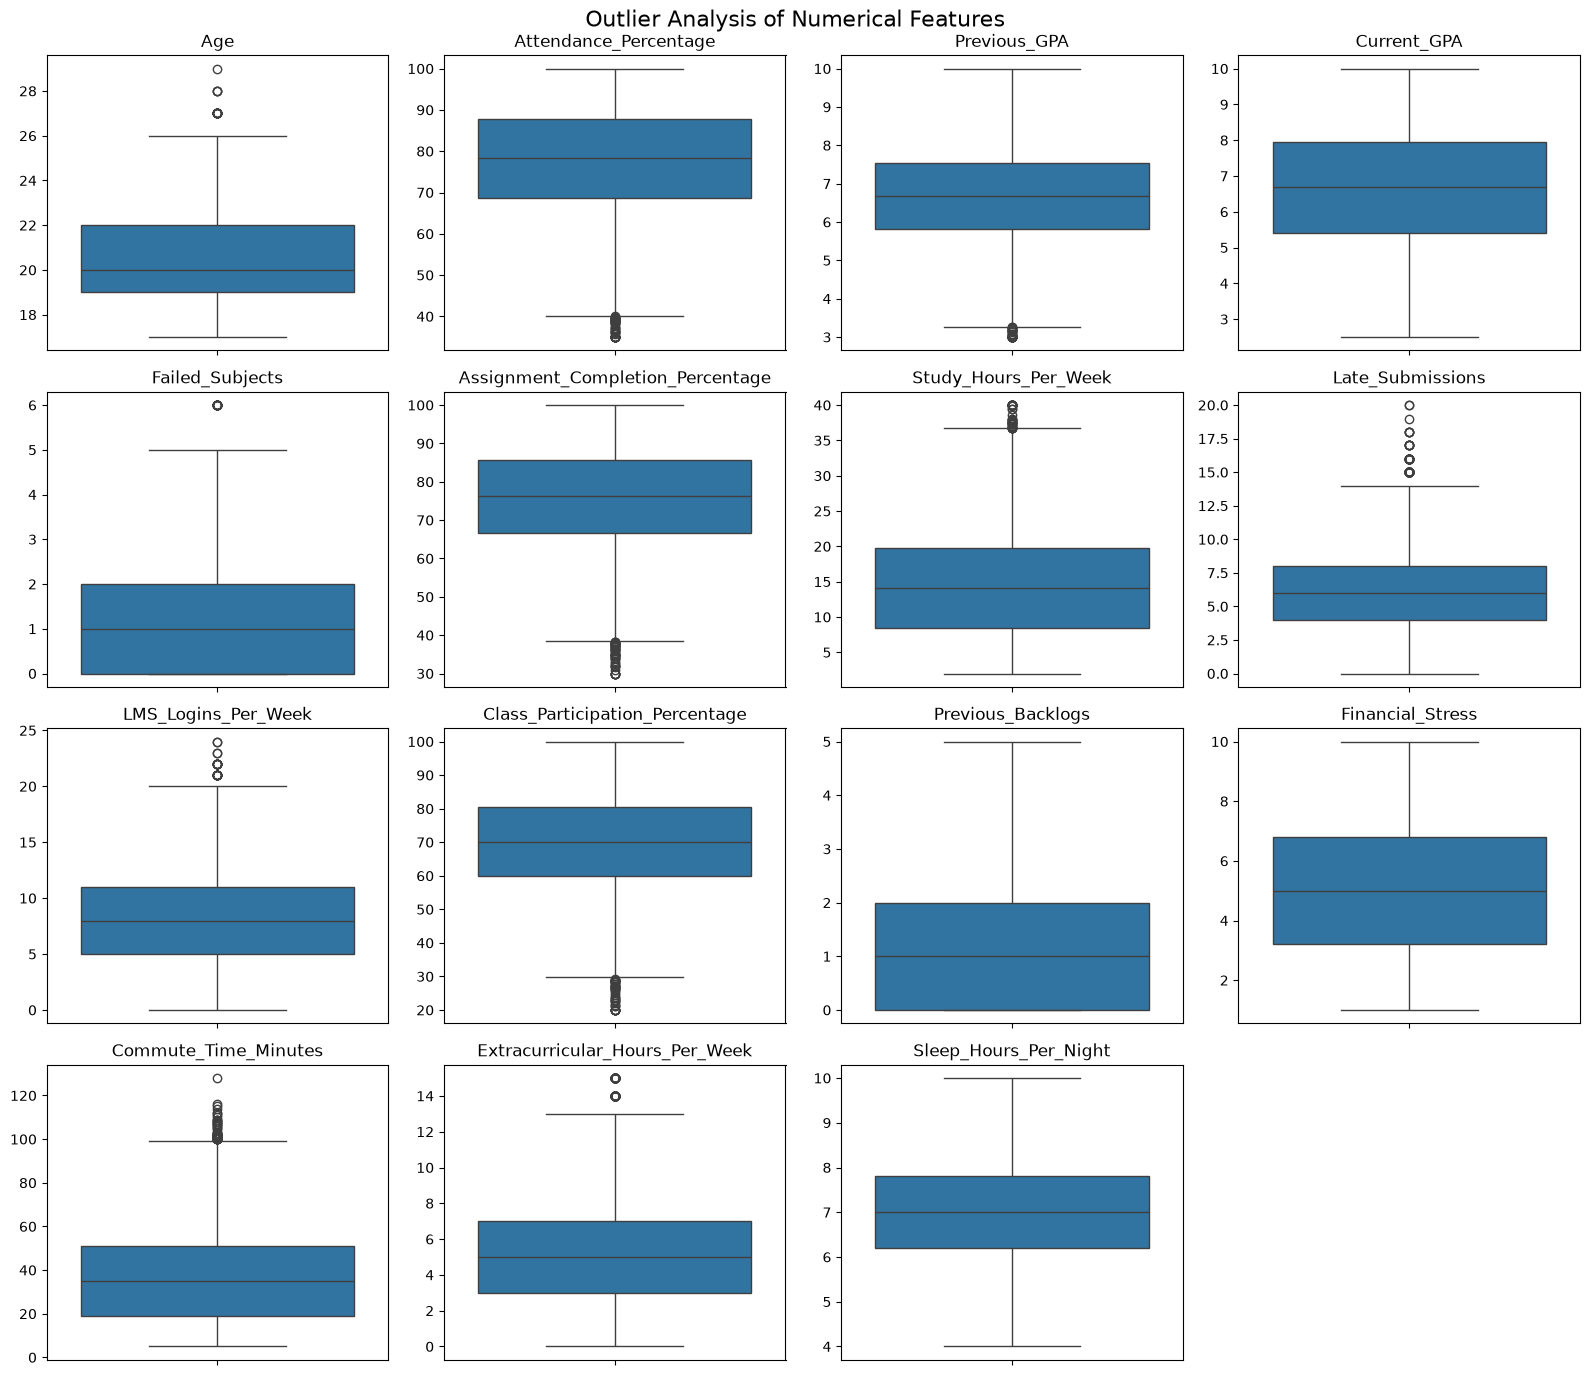

In [31]:
numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('')

# Hide unused plots
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Outlier Analysis of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

In [32]:
# Remove student id

df = df.drop('Student_ID', axis = 1)

In [33]:
#  verify

df.shape

(15000, 20)

In [34]:
#  seperating features and target

X = df.drop("Dropout_Risk",axis = 1)
y = df["Dropout_Risk"]

In [35]:
print("X.shape: ",X.shape)
print("y.shape: ",y.shape)

X.shape:  (15000, 19)
y.shape:  (15000,)


In [36]:
#  identifying numerical and categorical features

numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Attendance_Percentage', 'Previous_GPA', 'Current_GPA', 'Failed_Subjects', 'Assignment_Completion_Percentage', 'Study_Hours_Per_Week', 'Late_Submissions', 'LMS_Logins_Per_Week', 'Class_Participation_Percentage', 'Previous_Backlogs', 'Financial_Stress', 'Commute_Time_Minutes', 'Extracurricular_Hours_Per_Week', 'Sleep_Hours_Per_Night']

Categorical Features:
['Internet_Access', 'Scholarship', 'Academic_Support', 'Parent_Education']


C:\Users\Krishnakumar\AppData\Local\Temp\ipykernel_11280\1576459496.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [37]:
#  train test split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (12000, 19)
Testing set: (3000, 19)


In [38]:
#  verifying the target proportions

print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training target distribution:
Dropout_Risk
Low       0.60
Medium    0.25
High      0.15
Name: proportion, dtype: float64

Testing target distribution:
Dropout_Risk
Low       0.60
Medium    0.25
High      0.15
Name: proportion, dtype: float64


In [39]:
#  handle missing values

X_train.isnull().sum()

Age                                   0
Attendance_Percentage               121
Previous_GPA                          0
Current_GPA                           0
Failed_Subjects                       0
Assignment_Completion_Percentage    125
Study_Hours_Per_Week                  0
Late_Submissions                      0
LMS_Logins_Per_Week                 122
Class_Participation_Percentage        0
Previous_Backlogs                     0
Financial_Stress                    122
Commute_Time_Minutes                111
Internet_Access                       0
Scholarship                           0
Academic_Support                      0
Parent_Education                      0
Extracurricular_Hours_Per_Week        0
Sleep_Hours_Per_Night                 0
dtype: int64

In [40]:
# Fill missing numerical values using training-set medians

for col in numeric_features:
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

print("Missing values after imputation:")
print(X_train[numeric_features].isnull().sum())

Missing values after imputation:
Age                                 0
Attendance_Percentage               0
Previous_GPA                        0
Current_GPA                         0
Failed_Subjects                     0
Assignment_Completion_Percentage    0
Study_Hours_Per_Week                0
Late_Submissions                    0
LMS_Logins_Per_Week                 0
Class_Participation_Percentage      0
Previous_Backlogs                   0
Financial_Stress                    0
Commute_Time_Minutes                0
Extracurricular_Hours_Per_Week      0
Sleep_Hours_Per_Night               0
dtype: int64


In [41]:
print("Total missing values in X_train:", X_train.isnull().sum().sum())
print("Total missing values in X_test:", X_test.isnull().sum().sum())

Total missing values in X_train: 0
Total missing values in X_test: 0


In [42]:
# One-hot encode categorical features

X_train = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
)

# Make sure train and test have exactly the same columns
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (12000, 21)
X_test shape: (3000, 21)


In [43]:
# scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (12000, 21)
Scaled testing shape: (3000, 21)


In [44]:
# KNN


knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", round(knn_accuracy * 100, 2), "%")

KNN Accuracy: 84.03 %


In [45]:
# classification report

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Classification Report:
              precision    recall  f1-score   support

        High       0.84      0.76      0.79       450
         Low       0.90      0.94      0.92      1800
      Medium       0.69      0.66      0.68       750

    accuracy                           0.84      3000
   macro avg       0.81      0.78      0.80      3000
weighted avg       0.84      0.84      0.84      3000



In [46]:
#  confusion metrics

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("\nKNN Confusion Matrix:")
print(cm_knn)


KNN Confusion Matrix:
[[ 340    1  109]
 [   3 1687  110]
 [  64  192  494]]


In [47]:
#  tuning KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 43)
k_accuracies = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)

    y_pred = knn_model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    k_accuracies.append(accuracy)

for k, acc in zip(k_values, k_accuracies):
    print(f"K = {k:2d}  |  Accuracy = {acc*100:.2f}%")

K =  1  |  Accuracy = 79.67%
K =  2  |  Accuracy = 79.47%
K =  3  |  Accuracy = 82.73%
K =  4  |  Accuracy = 84.10%
K =  5  |  Accuracy = 84.03%
K =  6  |  Accuracy = 84.53%
K =  7  |  Accuracy = 85.07%
K =  8  |  Accuracy = 85.93%
K =  9  |  Accuracy = 85.40%
K = 10  |  Accuracy = 86.07%
K = 11  |  Accuracy = 86.10%
K = 12  |  Accuracy = 86.60%
K = 13  |  Accuracy = 86.17%
K = 14  |  Accuracy = 86.27%
K = 15  |  Accuracy = 86.60%
K = 16  |  Accuracy = 86.37%
K = 17  |  Accuracy = 86.47%
K = 18  |  Accuracy = 86.80%
K = 19  |  Accuracy = 86.67%
K = 20  |  Accuracy = 86.90%
K = 21  |  Accuracy = 86.80%
K = 22  |  Accuracy = 86.90%
K = 23  |  Accuracy = 86.53%
K = 24  |  Accuracy = 86.53%
K = 25  |  Accuracy = 86.53%
K = 26  |  Accuracy = 86.73%
K = 27  |  Accuracy = 86.93%
K = 28  |  Accuracy = 87.13%
K = 29  |  Accuracy = 87.33%
K = 30  |  Accuracy = 87.10%
K = 31  |  Accuracy = 87.10%
K = 32  |  Accuracy = 87.20%
K = 33  |  Accuracy = 87.07%
K = 34  |  Accuracy = 87.17%
K = 35  |  Acc

In [48]:
#  best k

best_k = k_values[k_accuracies.index(max(k_accuracies))]

print("Best K:", best_k)
print("Best KNN Accuracy:", round(max(k_accuracies) * 100, 2), "%")

Best K: 35
Best KNN Accuracy: 87.47 %


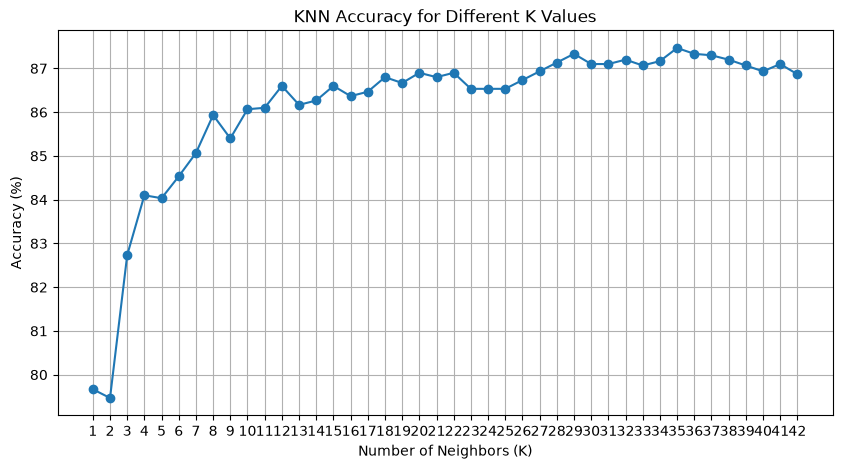

In [49]:
#  visualizing  it

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(k_values, [x * 100 for x in k_accuracies], marker='o')

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy (%)")
plt.title("KNN Accuracy for Different K Values")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [50]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 88.37 %


In [51]:
#  Classification Report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

        High       0.91      0.82      0.86       450
         Low       0.92      0.95      0.94      1800
      Medium       0.77      0.76      0.77       750

    accuracy                           0.88      3000
   macro avg       0.87      0.84      0.85      3000
weighted avg       0.88      0.88      0.88      3000



In [52]:
# Confusion matrix

print(confusion_matrix(y_test, y_pred_rf))

[[ 368    0   82]
 [   0 1711   89]
 [  38  140  572]]


In [53]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

Attendance_Percentage               0.175003
Current_GPA                         0.162154
Previous_GPA                        0.082185
Study_Hours_Per_Week                0.081669
Assignment_Completion_Percentage    0.081386
Financial_Stress                    0.071393
Failed_Subjects                     0.061508
Class_Participation_Percentage      0.055225
Late_Submissions                    0.046510
Commute_Time_Minutes                0.034003
LMS_Logins_Per_Week                 0.030958
Previous_Backlogs                   0.027931
Sleep_Hours_Per_Night               0.027042
Extracurricular_Hours_Per_Week      0.021364
Age                                 0.016451
Academic_Support_Yes                0.005461
Parent_Education_Undergraduate      0.004585
Scholarship_Yes                     0.004317
Parent_Education_Postgraduate       0.003866
Parent_Education_School             0.003702
Internet_Access_Yes                 0.003288
dtype: float64


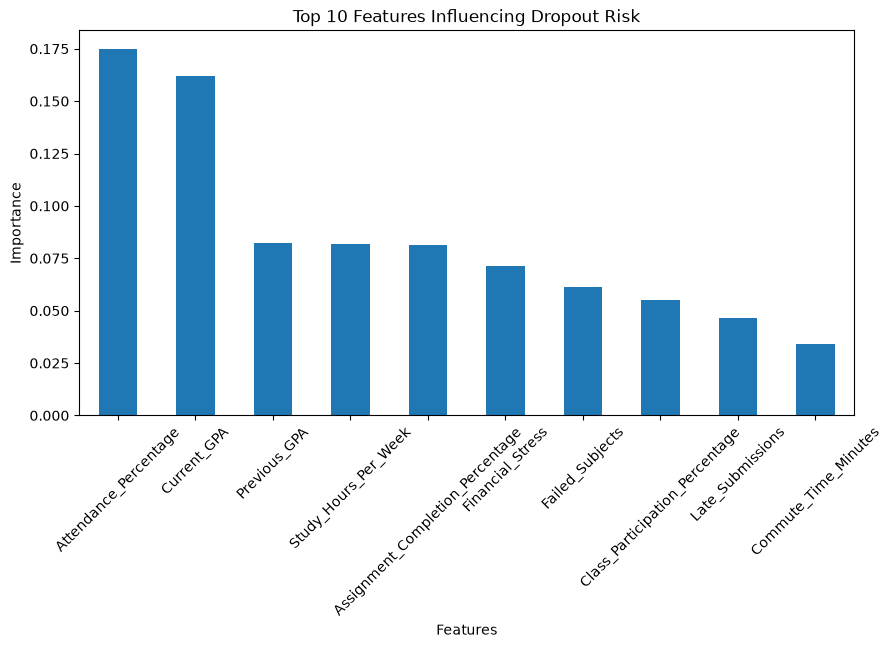

In [54]:
importance.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Features Influencing Dropout Risk")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [55]:
#  Hyperparameter tuning

rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

rf_tuned.fit(X_train_scaled, y_train)

pred = rf_tuned.predict(X_test_scaled)

accuracy = accuracy_score(y_test, pred)

print("Tuned Random Forest Accuracy:",
      round(accuracy * 100, 2), "%")

Tuned Random Forest Accuracy: 88.23 %


In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_ * 100, 2), "%")

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Accuracy: 87.41 %


In [57]:
best_rf = grid.best_estimator_

pred = best_rf.predict(X_test_scaled)

print("Test Accuracy:",
      round(accuracy_score(y_test, pred) * 100, 2), "%")

Test Accuracy: 88.43 %


In [58]:
#  Final model evaluation


best_pred = best_rf.predict(X_test_scaled)

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

        High       0.91      0.82      0.86       450
         Low       0.93      0.95      0.94      1800
      Medium       0.77      0.77      0.77       750

    accuracy                           0.88      3000
   macro avg       0.87      0.85      0.86      3000
weighted avg       0.88      0.88      0.88      3000



In [59]:
print(confusion_matrix(y_test, best_pred))

[[ 367    0   83]
 [   0 1707   93]
 [  37  134  579]]


In [60]:
# Model comparison

models = ['KNN', 'Random Forest']
test_accuracy = [87.47, 88.43]

for model, acc in zip(models, test_accuracy):
    print(model, "Test Accuracy:", acc, "%")

KNN Test Accuracy: 87.47 %
Random Forest Test Accuracy: 88.43 %


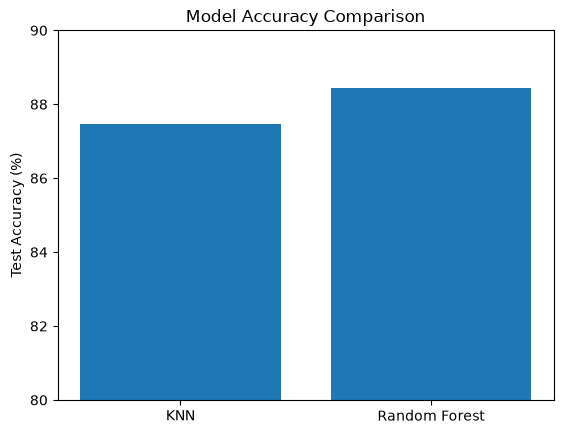

In [61]:
# Visual comparison

models = ['KNN', 'Random Forest']
accuracy = [87.47, 88.43]

plt.bar(models, accuracy)
plt.ylabel('Test Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(80, 90)
plt.show()

In [62]:
import joblib

# 'best_rf' and 'scaler' come from your grid search and scaling steps above
joblib.dump(best_rf, "dropout_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

print("Files saved successfully!")

Files saved successfully!


In [63]:
# Conclusion

# In this project, two machine-learning models, K-Nearest Neighbors (KNN) and Random Forest, were developed and evaluated for predicting student dropout risk.

# The KNN model achieved a test accuracy of *87.47%, while the Random Forest model achieved a higher test accuracy of **88.43%.

# The Random Forest model also achieved a **weighted F1-score of 0.88*, showing good overall classification performance.

# Based on the evaluation results, *Random Forest was selected as the final model* because it provided the highest test accuracy among the models evaluated.

# The results demonstrate that machine-learning techniques can be effectively used to classify students according to their dropout risk level.

# The final Random Forest model provides a useful predictive approach that could potentially support early identification of students who may require additional academic support.

# Overall, the project successfully developed, evaluated, and compared machine-learning models for student dropout-risk prediction, with *Random Forest achieving the best overall performance at 88.43% test accuracy*.
